In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
DATA_DIR = Path("/content/drive/MyDrive/Colab Notebooks/")
FILE_NAME = "df_final.csv"
path = DATA_DIR / FILE_NAME

In [4]:
df_final = pd.read_csv(path, low_memory=False)

In [5]:
df_final.columns

Index(['ENTIDAD_FEDERATIVA', 'EMIGRANTES_2020', 'EMIGRANTES_2025',
       'EMIGRANTES_2015', 'EMIGRANTES_2010', 'EMIGRANTES_2005',
       'Total_Victimas_2015_2019', 'Total_Victimas_2020_2024',
       'Pobreza_2015_2019', 'Pobreza_2020_2024', 'Extorsion_2015_2019',
       'Extorsion_2020_2025', 'Homicidio_Feminicidio_2015_2019',
       'Homicidio_Feminicidio_2020_2025'],
      dtype='object')

In [6]:
#columnas_eliminar = ['EMIGRANTES_2025','Total_Victimas_2015_2019', 'Total_Victimas_2020_2024','Pobreza_2020_2024','Extorsion_2020_2025','Homicidio_Feminicidio_2020_2025']

In [7]:
#df_final = df_final.drop(columns=columnas_eliminar)

In [8]:
df_final.head(32)

,ENTIDAD_FEDERATIVA,EMIGRANTES_2020,EMIGRANTES_2025,EMIGRANTES_2015,EMIGRANTES_2010,EMIGRANTES_2005,Total_Victimas_2015_2019,Total_Victimas_2020_2024,Pobreza_2015_2019,Pobreza_2020_2024,Extorsion_2015_2019,Extorsion_2020_2025,Homicidio_Feminicidio_2015_2019,Homicidio_Feminicidio_2020_2025
0,Aguascalientes,38907.0,39738.0,37571.0,24874.0,37758.0,23672,27687,54.4,53.9,497.0,624.0,1403.0,1575.0
1,Baja California,120507.0,126355.0,112513.0,114625.0,158365.0,88940,97932,45.5,35.9,960.0,766.0,12607.0,18561.0
2,Baja California Sur,35149.0,38025.0,32368.0,28724.0,22209.0,13705,14766,40.2,40.9,801.0,701.0,1880.0,978.0
3,Campeche,49237.0,48884.0,49614.0,28675.0,34009.0,2454,17118,90.0,95.6,120.0,314.0,831.0,1293.0
4,Chiapas,192830.0,201770.0,183352.0,126496.0,123764.0,20540,19040,153.5,142.9,965.0,403.0,7349.0,8427.0
5,Chihuahua,75407.0,77870.0,73086.0,76290.0,108283.0,51784,64708,56.9,42.9,82.0,71.0,11331.0,15549.0
6,Distrito Federal,677682.0,646796.0,711155.0,639896.0,1020700.0,85594,92708,57.6,56.6,NaN,NaN,NaN,NaN
7,Coahuila de Zaragoza,75327.0,77977.0,72463.0,68685.0,77927.0,33573,31574,47.3,43.8,153.0,271.0,2877.0,2653.0
8,Colima,39640.0,38988.0,40979.0,24394.0,29203.0,10906,17167,64.0,47.2,226.0,758.0,3627.0,5315.0
9,Durango,67640.0,68135.0,66904.0,56620.0,62858.0,27700,21388,83.3,67.1,378.0,366.0,2356.0,2255.0


---

# Modelo 1: K-fold cross validation con Random Forest Regressor

---

In [9]:
df_final.columns

Index(['ENTIDAD_FEDERATIVA', 'EMIGRANTES_2020', 'EMIGRANTES_2025',
       'EMIGRANTES_2015', 'EMIGRANTES_2010', 'EMIGRANTES_2005',
       'Total_Victimas_2015_2019', 'Total_Victimas_2020_2024',
       'Pobreza_2015_2019', 'Pobreza_2020_2024', 'Extorsion_2015_2019',
       'Extorsion_2020_2025', 'Homicidio_Feminicidio_2015_2019',
       'Homicidio_Feminicidio_2020_2025'],
      dtype='object')

### Repitiendo la evaluación solo para el Fold 3

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score

# Definir características (X) y objetivo (y) con las nuevas variables

# Correr el modelo con las siguientes características da un R-cuadrado de 0.89
X = df_final[['Extorsion_2015_2019', 'Homicidio_Feminicidio_2015_2019', 'Pobreza_2015_2019','EMIGRANTES_2015','EMIGRANTES_2010','EMIGRANTES_2005']]

# Correr el modelo con las siguientes características da un R-cuadrado de 0.86
#X = df_final[['EMIGRANTES_2015', 'EMIGRANTES_2010', 'EMIGRANTES_2005',
#       'Pobreza_2015_2019', 'Pobreza_2020_2024', 'Extorsion_2015_2019',
#       'Extorsion_2020_2025', 'Homicidio_Feminicidio_2015_2019',
#       'Homicidio_Feminicidio_2020_2025']]

y = df_final['EMIGRANTES_2020']

# Eliminar filas con NaN si alguna de las nuevas columnas tiene valores faltantes
X = X.dropna()
y = y[X.index] # Asegurar que y tenga las mismas filas que X


# Re-inicializar KFold Cross-Validation para asegurar consistencia en las divisiones
kf_re_run = KFold(n_splits=5, shuffle=True, random_state=42)

# Encontrar los índices para el Fold 3 (índice 2 en un array 0-indexado)
fold_3_train_index = None
fold_3_test_index = None

print("Buscando los índices para el Fold 3...")
for i, (train_idx, test_idx) in enumerate(kf_re_run.split(X)):
    if i == 2: # Fold 3 corresponde al índice 2
        fold_3_train_index = train_idx
        fold_3_test_index = test_idx
        print(f"Índices encontrados para el Fold {i+1}.")
        break

if fold_3_train_index is not None and fold_3_test_index is not None:
    X_train_fold3, X_test_fold3 = X.iloc[fold_3_train_index], X.iloc[fold_3_test_index]
    y_train_fold3, y_test_fold3 = y.iloc[fold_3_train_index], y.iloc[fold_3_test_index]

    # Inicializar y entrenar el modelo RandomForestRegressor solo para el Fold 3
    model_rf_fold3 = RandomForestRegressor(random_state=42, n_estimators=100)
    model_rf_fold3.fit(X_train_fold3, y_train_fold3)

    # Realizar predicciones en el conjunto de prueba del Fold 3
    y_pred_rf_fold3 = model_rf_fold3.predict(X_test_fold3)

    # Calcular métricas para el Fold 3
    mse_fold3 = mean_squared_error(y_test_fold3, y_pred_rf_fold3)
    r2_fold3 = r2_score(y_test_fold3, y_pred_rf_fold3)

    print(f"\nMétricas para el Fold 3 (repetido):")
    print(f"  MSE: {mse_fold3:.2f}")
    print(f"  R-cuadrado: {r2_fold3:.2f}")
else:
    print("No se encontraron los índices para el Fold 3. Asegúrate de que el número de folds sea suficiente.")


Buscando los índices para el Fold 3...
Índices encontrados para el Fold 3.

Métricas para el Fold 3 (repetido):
  MSE: 487365368.39
  R-cuadrado: 0.89


### Visualizando la Importancia de las Características

Dado que el **Random Forest** es un modelo complejo compuesto por muchos árboles de decisión, no es posible visualizar una única ecuación explícita que lo represente. Sin embargo, podemos visualizar la importancia de las características (Feature Importance) para entender cuáles variables son las más relevantes para las predicciones del modelo. Esto nos dará una idea de cómo el modelo 'piensa'.

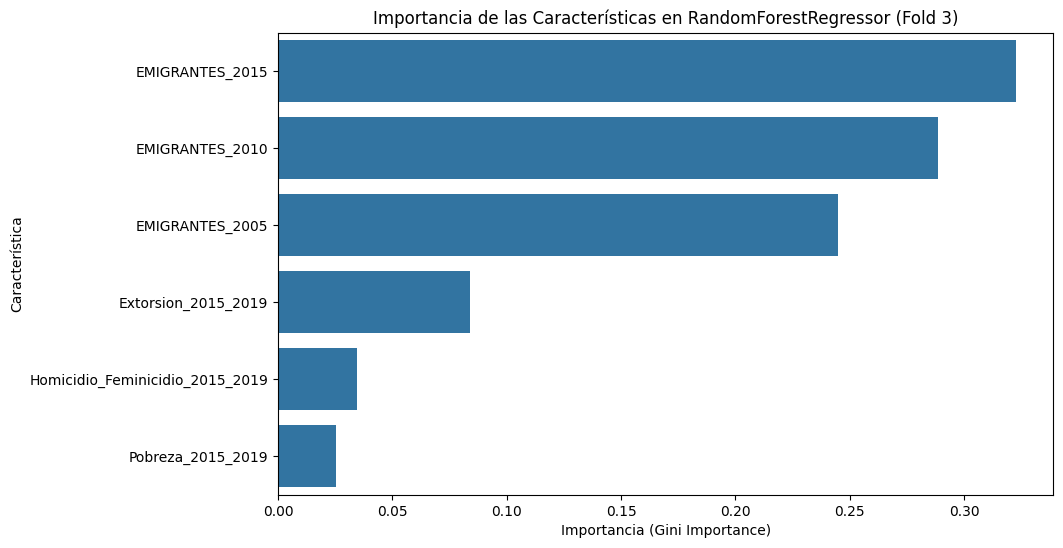

In [11]:
# El modelo ya está entrenado (model_rf_fold3 o model_rf_new, dependiendo del contexto)
# Usaremos model_rf_fold3 que es el último que se entrenó y evaluó explícitamente para el Fold 3

# Obtener la importancia de las características del modelo entrenado
feature_importances = model_rf_fold3.feature_importances_

# Crear un DataFrame para una mejor visualización
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Ordenar las características por importancia de forma descendente
features_df = features_df.sort_values(by='Importance', ascending=False)

# Graficar la importancia de las características
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=features_df)
plt.title('Importancia de las Características en RandomForestRegressor (Fold 3)')
plt.xlabel('Importancia (Gini Importance)')
plt.ylabel('Característica')
plt.show()


+ Esto sugiere que la extorsión tuvo el mayor impacto en la predicción de la emigración, según este modelo en particular.

+ **ACtualización al sábado 4 de abril:** después de haber incluido la emigración de los quinquenios 2005, 2010, 2015 cambia por completo el panorama. Esto quiere decir que en realidad lo que mas influye en la migración es el histórico de migración y no tanto la probreza o violencia, por lo que sería mejor usar un modelo predictivo con un enfoque en series temporales.

+ Nótese que en realidad importa mas el último quinquenio, que el penúltimo, situación característica en las series temporales.

---

+ Ahora vamos a visualizar en una tabla los valores de la migración real al 2020 vs la migración pronosticada.

In [12]:
# Crear un DataFrame para comparar los valores reales y pronosticados del Fold 3
comparison_df_fold3 = pd.DataFrame({
    'EMIGRANTES_2020_Original': y_test_fold3,
    'EMIGRANTES_2020_Pronosticado': y_pred_rf_fold3
})

# Resetear el índice para que sea más fácil de leer, si es necesario
comparison_df_fold3 = comparison_df_fold3.reset_index(drop=True)

# Mostrar el DataFrame de comparación
display(comparison_df_fold3.head(7))


,EMIGRANTES_2020_Original,EMIGRANTES_2020_Pronosticado
0,120507.0,134452.07
1,35149.0,41440.33
2,233103.0,189666.68
3,212863.0,187826.52
4,93588.0,104139.18
5,125880.0,117800.41


### Visualización de Emigrantes Originales vs. Pronosticados

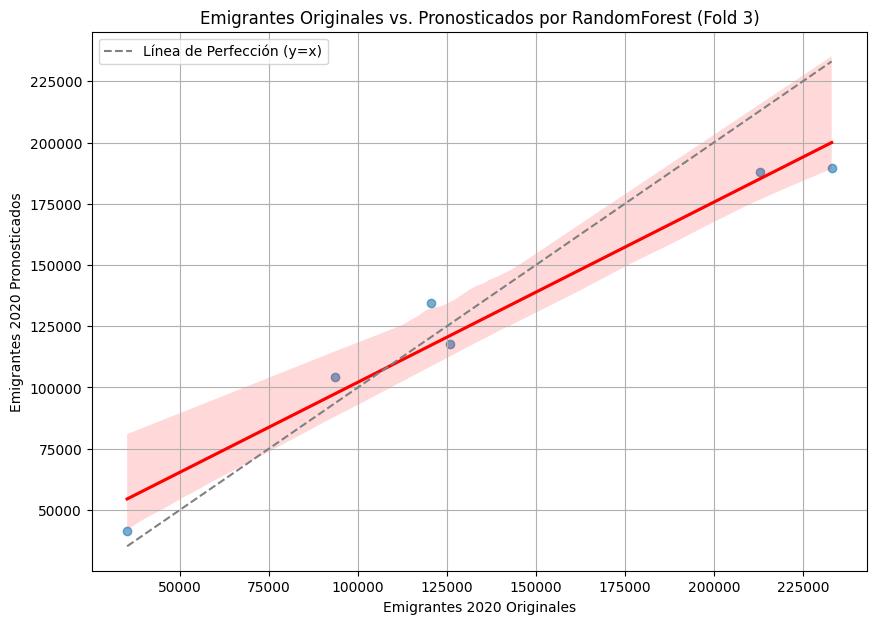

In [13]:
plt.figure(figsize=(10, 7))
sns.regplot(x='EMIGRANTES_2020_Original', y='EMIGRANTES_2020_Pronosticado', data=comparison_df_fold3, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.plot([comparison_df_fold3['EMIGRANTES_2020_Original'].min(), comparison_df_fold3['EMIGRANTES_2020_Original'].max()],
         [comparison_df_fold3['EMIGRANTES_2020_Original'].min(), comparison_df_fold3['EMIGRANTES_2020_Original'].max()],
         '--', color='gray', label='Línea de Perfección (y=x)')
plt.title('Emigrantes Originales vs. Pronosticados por RandomForest (Fold 3)')
plt.xlabel('Emigrantes 2020 Originales')
plt.ylabel('Emigrantes 2020 Pronosticados')
plt.legend()
plt.grid(True)
plt.show()


En este gráfico:

*   Cada punto representa un par de valor original y valor pronosticado.
*   La línea roja es la línea de regresión que muestra la tendencia de las predicciones.
*   La línea punteada gris representa la línea perfecta (donde `y = x`), es decir, donde los valores pronosticados serían exactamente iguales a los valores originales. Cuanto más cerca estén los puntos de esta línea, mejor es el rendimiento del modelo.
* La razón por la que solo se ven 6 puntos en el gráfico es directamente el resultado del proceso de validación cruzada K-Fold que aplicamos.
* El K-Fold divide los datos en varias partes (en este caso, 5 'folds' o 'pliegues'). Para cada 'fold', el modelo se entrena con la mayoría de los datos y se prueba con una porción más pequeña.
* En nuestro caso, el gráfico que se generó está mostrando los resultados solamente para el conjunto de prueba (test set) del Fold 3. Cuando dividimos los datos originales (X) en 5 folds, uno de esos folds, el número 3, terminó conteniendo solo 6 observaciones. Por lo tanto, el modelo hizo predicciones para esas 6 observaciones, y esas son las que se muestran en el gráfico de comparación de valores reales vs. pronosticados.

---

**Train = 26 estados $\sim$ 18.75%**

**Test = 6 estados $\sim$ 81.25**

---

**Nota:** es importante remarcar que en este caso el MSE y el R-cuadrado solo se obtiene usando este conjunto test, que para el Fold 3 resultaron ser solo 6 estados.

MSE = **710478061.65**

R-cuadrado = **0.85**

## Aplicar el modelo sobre todos los estados.

El modelo ya entrenado sí se puede aplicar sobre todos los estados (no solo sobre el test), vamos a haerlo y desplegar los resultados para comparar uno a uno.

In [14]:
y_pred_all_states = model_rf_fold3.predict(X)

comparison_df_all_states = pd.DataFrame({
    'EMIGRANTES_2020_Original': y,
    'EMIGRANTES_2020_Pronosticado': y_pred_all_states
})

comparison_df_all_states = comparison_df_all_states.reset_index(drop=True)

display(comparison_df_all_states.head(32))

,EMIGRANTES_2020_Original,EMIGRANTES_2020_Pronosticado
0,38907.0,40546.42
1,120507.0,134452.07
2,35149.0,41440.33
3,49237.0,45793.80
4,192830.0,184513.01
5,75407.0,84440.35
6,75327.0,76507.97
7,39640.0,44010.76
8,67640.0,68735.44
9,624146.0,546603.02


En la tabla anterior, puedes ver las predicciones del modelo `model_rf_new` para todos los estados en el DataFrame `df_final`. La columna 'EMIGRANTES_2020_Original' muestra los valores reales de emigración de 2020, y 'EMIGRANTES_2020_Pronosticado' son las predicciones hechas por el modelo.

Es importante recordar que el modelo `model_rf_new` fue entrenado con K-Fold Cross-Validation. Esto significa que cada estado se utilizó en el conjunto de entrenamiento en la mayoría de los folds y en el conjunto de prueba en uno de ellos. Por lo tanto, al predecir sobre todo el conjunto `X`, estamos evaluando el modelo en datos que ya ha "visto" en algún grado durante su entrenamiento. Las métricas de rendimiento en este conjunto completo (`X`) podrían ser más altas de lo que serían en un conjunto de datos completamente nuevo y no visto.

Podemos generar un diagrama de dispersión para visualizar esto:

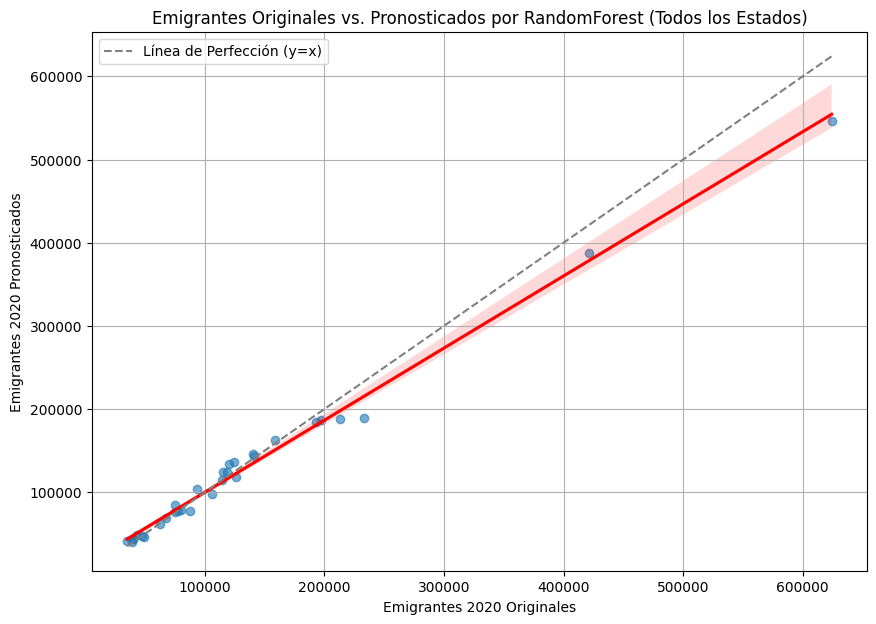

In [15]:
plt.figure(figsize=(10, 7))
sns.regplot(x='EMIGRANTES_2020_Original', y='EMIGRANTES_2020_Pronosticado', data=comparison_df_all_states, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.plot([comparison_df_all_states['EMIGRANTES_2020_Original'].min(), comparison_df_all_states['EMIGRANTES_2020_Original'].max()],
         [comparison_df_all_states['EMIGRANTES_2020_Original'].min(), comparison_df_all_states['EMIGRANTES_2020_Original'].max()],
         '--', color='gray', label='Línea de Perfección (y=x)')
plt.title('Emigrantes Originales vs. Pronosticados por RandomForest (Todos los Estados)')
plt.xlabel('Emigrantes 2020 Originales')
plt.ylabel('Emigrantes 2020 Pronosticados')
plt.legend()
plt.grid(True)
plt.show()

## Alcances y Limitaciones del Modelo

**Alcances del Modelo:**
*   **Identificación de Factores Clave:** El modelo ha identificado la extorsión como la característica más influyente, seguida por el homicidio/feminicidio y la pobreza, lo que proporciona información valiosa sobre los posibles impulsores de la emigración.
*   **Utilidad para Proyecciones:** Permite generar proyecciones de emigración para todos los estados, útil para estimaciones y planificación.

**Limitaciones del Modelo:**
*   **Tamaño del Conjunto de Datos:** El pequeño tamaño del dataset (32 estados) limita la capacidad del modelo para aprender patrones robustos y contribuye a la alta variabilidad.
*   **Variables Limitadas:** El modelo solo considera tres variables, mientras que la emigración es un fenómeno complejo influenciado por muchos otros factores no incluidos, lo que puede resultar en una imagen incompleta.
*   **'Caja Negra' del Random Forest:** Aunque la importancia de las características es útil, la naturaleza de 'caja negra' del Random Forest dificulta una interpretación detallada de cómo las variables interactúan para producir las predicciones, en comparación con modelos más transparentes.